In [1]:
import getpass
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv


load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [2]:
from sqlalchemy import create_engine, Table, Column, Integer, String, MetaData,ForeignKey,Float
from sqlalchemy.orm import declarative_base, sessionmaker
import pymysql  # ✅ 显式导入，让 SQLAlchemy 识别
from faker import Faker
import random
from langchain_core.messages import AnyMessage, SystemMessage,HumanMessage,ToolMessage

# 创建基类
Base = declarative_base()

class SalesData(Base):
    __tablename__ = 'sales_data'
    sales_id = Column(Integer, primary_key=True)
    product_id= Column(Integer,ForeignKey('product_information.product_id'))
    employee_id=Column(Integer)
    customer_id=Column(Integer,ForeignKey('customer_information.customer_id'))
    sale_date=Column(String(50))
    quantity=Column(Integer)
    amount=Column(Float)
    discount=Column(Float)
    
class CustomerInformation(Base):
    __tablename__ = 'customer_information'
    customer_id=Column(Integer,primary_key=True)
    customer_name=Column(String(50))
    contact_info=Column(String(50))
    region=Column(String(50))
    customer_type=Column(String(50))
    
class ProductInformation(Base):
    __tablename__ = 'product_information'
    product_id=Column(Integer,primary_key=True)
    product_name=Column(String(50))
    category=Column(String(50))
    unit_price=Column(Float)
    stock_level=Column(Integer)
    
class CompetitorAnalysis(Base):
    __tablename__ = 'competitor_analysis'
    competitor_id=Column(Integer,primary_key=True)
    competitor_name=Column(String(50))
    region=Column(String(50))
    market_share=Column(Float)
    

# ✅ mysql:// → mysql+pymysql://，用 PyMySQL 驱动
DATABASE_URI = os.getenv("DATABASE_URI")
engine = create_engine(DATABASE_URI, echo=True)
Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()

2026-06-30 17:45:38,013 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-06-30 17:45:38,014 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-30 17:45:38,016 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-06-30 17:45:38,016 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-30 17:45:38,018 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-06-30 17:45:38,019 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-30 17:45:38,020 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-30 17:45:38,022 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`sales_data`
2026-06-30 17:45:38,023 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-30 17:45:38,027 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`customer_information`
2026-06-30 17:45:38,027 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-30 17:45:38,030 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`product_information`
2026-06-30 17:45:38,031 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-30 17:

In [3]:
from pydantic import BaseModel,Field
from langchain_core.tools import tool
from typing import Union,Optional

class AddSaleSchema(BaseModel):
    product_id:int
    employee_id:int
    customer_id:int
    sale_date:str
    quantity:int
    amount:float
    discount:float
    
class DeleteSaleSchema(BaseModel):
    sales_id:int

class UpdateSaleSchema(BaseModel):
    sales_id:int
    quantity:int
    amount:float

class QuerySalesSchema(BaseModel):
    sales_id:int

class QueryCompetitorSchema(BaseModel):
    competitor_id:Optional[int]=None
    competitor_name:Optional[str]=None

class QueryCustomerSchema(BaseModel):
    customer_id:Optional[int]=None
    customer_name:Optional[str]=None

class QueryProductSchema(BaseModel):
    product_id:Optional[int]=None
    product_name:Optional[str]=None

@tool(args_schema=AddSaleSchema)
def add_sale(product_id,employee_id,customer_id,sale_date,quantity,amount,discount):
    """Add sale record to the database"""
    session=Session()
    try:
        new_sale=SalesData(
            product_id=product_id,
            employee_id=employee_id,
            customer_id=customer_id,
            sale_date=sale_date,
            quantity=quantity,
            amount=amount,
            discount=discount
        )
        session.add(new_sale)
        session.commit()
        return {"messages":["销售记录添加成功。"]}
    except Exception as e:
        return {"messages":[f"添加失败，错误原因：{e}"]}
    finally:
        session.close()

@tool(args_schema=DeleteSaleSchema)
def delete_sale(sales_id):
    """Delete sale record from the database."""
    session=Session()
    try:
        sale_to_delete=session.query(SalesData).filter(SalesData.sales_id == sales_id).first()
        if sale_to_delete:
            session.delete(sale_to_delete)
            session.commit()
            return {"messages":["销售记录删除成功。"]}
        else:
            return {"messages":[f"未找到销售记录ID:{sales_id}"]}
    except Exception as e:
        return {"messages":[f"删除失败，错误原因:{e}"]}
    finally:
        session.close()
        
@tool(args_schema=UpdateSaleSchema)
def update_sale(sales_id,quantity,amount):
    """Update sale record in the database"""
    session=Session()
    try:
        sale_to_update=session.query(SalesData).filter(SalesData.sales_id == sales_id).first()
        if sale_to_update:
            sale_to_update.quantity=quantity
            sale_to_update.amount=amount
            session.commit()
            return {"messages":["销售记录更新成功。"]}
        else:
            return {"messages":[f"未找到销售记录ID:{sales_id}"]}
    except Exception as e:
        return {"messages":[f"更新失败，错误原因:{e}"]}
    finally:
        session.close()

@tool(args_schema=QuerySalesSchema)
def query_sales(sales_id):
    """Query sale record by sales_id in the database"""
    session=Session()
    try:
        sale_data=session.query(SalesData).filter(SalesData.sales_id == sales_id).first()
        if sale_data:
            return {
                "sales_id":sale_data.sales_id,
                "product_id":sale_data.product_id,
                "employee_id":sale_data.employee_id,
                "customer_id":sale_data.customer_id,
                "sale_date":sale_data.sale_date,
                "quantity":sale_data.quantity,
                "amount":sale_data.amount,
                "discount":sale_data.discount
            }
        else:
            return {"messages":[f"未找到销售记录ID:{sales_id}"]}
    except Exception as e:
        return {"messages":[f"查询失败，错误原因:{e}"]}
    finally:
        session.close()

@tool(args_schema=QueryCompetitorSchema)
def query_competitors(competitor_id:Optional[int]=None, competitor_name:Optional[str]=None):
    """Query competitor information. If no parameters provided, returns ALL competitors.
    Can filter by competitor_id or competitor_name (fuzzy match)."""
    session=Session()
    try:
        query = session.query(CompetitorAnalysis)
        if competitor_id is not None:
            query = query.filter(CompetitorAnalysis.competitor_id == competitor_id)
        if competitor_name is not None:
            query = query.filter(CompetitorAnalysis.competitor_name.like(f"%{competitor_name}%"))
        results = query.all()
        if results:
            return [
                {
                    "competitor_id": c.competitor_id,
                    "competitor_name": c.competitor_name,
                    "region": c.region,
                    "market_share": c.market_share
                }
                for c in results
            ]
        else:
            return {"messages": ["未找到匹配的竞争对手信息。"]}
    except Exception as e:
        return {"messages": [f"查询失败，错误原因:{e}"]}
    finally:
        session.close()

@tool(args_schema=QueryCustomerSchema)
def query_customers(customer_id:Optional[int]=None, customer_name:Optional[str]=None):
    """Query customer information. If no parameters provided, returns ALL customers.
    Can filter by customer_id or customer_name (fuzzy match)."""
    session=Session()
    try:
        query = session.query(CustomerInformation)
        if customer_id is not None:
            query = query.filter(CustomerInformation.customer_id == customer_id)
        if customer_name is not None:
            query = query.filter(CustomerInformation.customer_name.like(f"%{customer_name}%"))
        results = query.all()
        if results:
            return [
                {
                    "customer_id": c.customer_id,
                    "customer_name": c.customer_name,
                    "contact_info": c.contact_info,
                    "region": c.region,
                    "customer_type": c.customer_type
                }
                for c in results
            ]
        else:
            return {"messages": ["未找到匹配的客户信息。"]}
    except Exception as e:
        return {"messages": [f"查询失败，错误原因:{e}"]}
    finally:
        session.close()

@tool(args_schema=QueryProductSchema)
def query_products(product_id:Optional[int]=None, product_name:Optional[str]=None):
    """Query product information. If no parameters provided, returns ALL products.
    Can filter by product_id or product_name (fuzzy match)."""
    session=Session()
    try:
        query = session.query(ProductInformation)
        if product_id is not None:
            query = query.filter(ProductInformation.product_id == product_id)
        if product_name is not None:
            query = query.filter(ProductInformation.product_name.like(f"%{product_name}%"))
        results = query.all()
        if results:
            return [
                {
                    "product_id": p.product_id,
                    "product_name": p.product_name,
                    "category": p.category,
                    "unit_price": p.unit_price,
                    "stock_level": p.stock_level
                }
                for p in results
            ]
        else:
            return {"messages": ["未找到匹配的产品信息。"]}
    except Exception as e:
        return {"messages": [f"查询失败，错误原因:{e}"]}
    finally:
        session.close()

In [4]:
from typing import Annotated
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
import json

repl=PythonREPL()

@tool
def python_repl(
    code:Annotated[str,"The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result=repl.run(code)
    except BaseException as e:
        return f"Failed to execute.Error: {repr(e)}"
    result_str=f"Successfully executed:\n\`\`\` python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

C:\Users\13840\AppData\Local\Temp\ipykernel_6472\3491660334.py:3: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL


In [5]:
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph,START,END
from langchain.agents import create_agent

In [6]:
db_agent=create_agent(
    llm,
    tools=[add_sale, delete_sale, update_sale, query_sales, query_competitors, query_customers, query_products],
    system_prompt="""You are a database query agent for MySQL. Your ONLY job is to query 
the database using tools and return the raw data. 

YOUR AVAILABLE TOOLS:
- query_sales: Query sales records by sales_id
- query_competitors: Query competitors (pass no args to list ALL competitors)
- query_customers: Query customers (pass no args to list ALL customers)
- query_products: Query products (pass no args to list ALL products)
- add_sale / delete_sale / update_sale: Modify sales records

CRITICAL RULES:
- NEVER generate charts, graphs, visualizations, or Mermaid syntax.
- NEVER add analysis, summaries, or conclusions to the data.
- NEVER format data as markdown tables.
- Only use tools to query data. Return the results as-is.
- When user asks '有哪些公司' or 'list companies', use query_competitors with no arguments to list all.
- When user asks '有哪些客户' or 'list customers', use query_customers with no arguments.
- When user asks '有哪些产品' or 'list products', use query_products with no arguments.
- This is a multi-agent system: another agent (coder) handles all chart generation."""
)

In [7]:
# response=db_agent.invoke({"messages":"帮我查询销售id是5,6，7的数据"})
# response

In [8]:
code_agent=create_agent(
    llm,
    tools=[python_repl],
    system_prompt="""You are a Python code execution agent. Your job is to write 
and execute Python code to generate charts, graphs, and data visualizations.
- Use matplotlib (with Chinese font support) to create bar charts, pie charts, etc.
- Use the python_repl tool to execute your code.
- Extract data values from the conversation history to populate the chart.
- When you see JSON data (with fields like sales_id, amount, quantity), parse it 
  and use it to create the visualization.
- Print a confirmation message when the chart is successfully generated."""
)

In [9]:
# response=db_agent.invoke({"messages":"帮我查询销售id是5,6，7的数据"})
# codeResponse=code_agent.invoke({"messages":["根据messages中的数据生成一个柱状图"]+response["messages"]})
# codeResponse

In [10]:
import operator
from typing import Annotated

from langgraph.graph import StateGraph,MessagesState,START,END

class AgentState(MessagesState):
    next:str
    step_count:Annotated[int,operator.add]

In [11]:
def db_node(state:AgentState):
    # ✅ 只传递 messages，避免将 next/step_count 等状态字段传给子 agent
    result=db_agent.invoke({"messages": state["messages"]})
    # ✅ 提取 ToolMessage（工具返回的原始数据），而不是 Agent 的最终对话回复
    tool_messages = [m for m in result["messages"] if isinstance(m, ToolMessage)]
    if tool_messages:
        # 构建干净的原始数据文本
        data_lines = ["[sqler 查询结果]:"]
        for tm in tool_messages:
            data_lines.append(tm.content)  # tm.content 已经是 JSON 字符串
        data_summary = "\n".join(data_lines)
    else:
        # 如果没有工具调用（例如 Agent 直接回复），使用原始回复
        data_summary = result["messages"][-1].content
    
    return {"messages": [
        HumanMessage(content=data_summary, name="sqler")
    ]}

In [12]:
def code_node(state:AgentState):
    # ✅ 只传递 messages，避免将 next/step_count 等状态字段传给子 agent
    result=code_agent.invoke({"messages": state["messages"]})
    # 提取代码执行相关的消息（优先工具结果，其次AI最终回复）
    tool_messages = [m for m in result["messages"] if isinstance(m, ToolMessage)]
    if tool_messages:
        # 取最后一条工具消息（通常是 Python REPL 的输出）
        final_content = "[coder 图表生成结果]:\n" + tool_messages[-1].content
    else:
        final_content = result["messages"][-1].content
    return {"messages": [
        HumanMessage(content=final_content, name="coder")
    ]}

In [13]:
from langchain.messages import HumanMessage
from langchain_core.prompts import PromptTemplate
from langchain_community.chains.graph_qa.cypher import GraphCypherQAChain
from langchain_community.graphs import Neo4jGraph

graph = Neo4jGraph(
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    database=os.getenv("NEO4J_DATABASE")
)

def graph_kg(state:AgentState):
    messages=state["messages"][-1]
    
    # 自定义 Cypher 生成 prompt - 加强约束
    # --- 自定义 prompt：强调用精确 ID + CONTAINS 兜底 ---
    CUSTOM_PROMPT = PromptTemplate(
        input_variables=["schema", "question"],
        template="""Task: Generate ONE Cypher query to answer the question about a Chinese company.

    CRITICAL RULES:
    1. Identify the entity keyword from the question (e.g. "小米", "苹果", "华为")
    2. ALWAYS use CONTAINS for text matching — NEVER use = for Chinese company names
    Example: WHERE n.id CONTAINS '小米'  (NOT: WHERE n.id = '小米公司')
    3. Match ONLY the keyword part (before 公司/科技/技术), because the full name in the database may differ
    4. Return ONLY the Cypher statement. No markdown, no explanation, no ```cypher```.

    Schema:
    {schema}

    Question: {question}

    Cypher:"""
    )

    cypher_chain=GraphCypherQAChain.from_llm(
        graph=graph,
        cypher_llm=llm,
        cypher_prompt=CUSTOM_PROMPT,
        qa_llm=llm,
        validate_cypher=True,
        verbose=True,
        allow_dangerous_requests=True
    )
    response=cypher_chain.invoke(messages.content)
    final_response=[HumanMessage(content=response['result'],name="graph_kg")]
    return {"messages":final_response}

C:\Users\13840\AppData\Local\Temp\ipykernel_6472\2869983932.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.chains.graph_qa.cypher import GraphCypherQAChain
C:\Users\13840\AppData\Local\Temp\ipykernel_6472\2869983932.py:6: LangChainDeprecationWarning: The class `Neo4jGraph` was deprecated in LangChain 0.3.8 and will be removed in 1.0. An updated version of the class exists in the `langchain-neo4j package and should be used instead. To use it run `pip install -U `langchain-neo4j` and import as `from `langchain_neo4j import Neo4jGraph``.
  graph = Neo4jGraph(


In [14]:
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_milvus import Milvus
from langchain_ollama import OllamaEmbeddings

# 使用向量数据库
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

# 打开文件，并赋予读取模式
with open("./company.txt",'r',encoding='utf-8') as file:
    content=file.read()
    print(content)



documents=[Document(page_content=content)]

chunk_size=250
chunk_overlap=30
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,chunk_overlap=chunk_overlap
)

splits=text_splitter.split_documents(documents)

# DeepSeek 没有 Embedding API（/v1/embeddings 不存在，404）
# 改用本地 Ollama 的 bge-m3 模型 —— 支持中英双语，1024维向量
embeddings = OllamaEmbeddings(
    model="bge-m3",
    base_url="http://localhost:11434"
)

vectorstore = Milvus.from_documents(
    documents=splits,
    collection_name="company_rag_milvus",
    embedding=embeddings,
    drop_old=True,   # ← 关键！删除之前错误 schema 的旧 collection
    connection_args={
        "uri": os.getenv("zilliz_url"),
        "token": f"{os.getenv('zilliz_User')}:{os.getenv('zilliz_Password')}",
    }
)

def vec_kg(state:AgentState):
    
    messages=state["messages"][-1]
    question=messages.content
    
    prompt=PromptTemplate(
        template="""
            You are an assistant for question-answering tasks.
            Use the following pieces of retrieved context to answer the question.
            
            IMPORTANT: If the question asks about "which companies" or "list companies", 
            you MUST list EVERY company name that appears in ANY of the context chunks.
            Do NOT omit any company. Scan all context pieces carefully.
            
            If you don't know the answer, just say so honestly.
            
            Question: {question}
            Context: {context}
            Answer:
        """,
        input_variables={"question",'context'}
    )
    
    rag_chain=prompt | llm | StrOutputParser()
    # ✅ 修复1: 使用变量 question（而非字符串 "question"）
    # ✅ 修复2: 增大 k=6 确保覆盖所有公司文档片段
    retriever=vectorstore.as_retriever(search_kwargs={"k":6})
    docs=retriever.invoke(question)
    generation=rag_chain.invoke({"context":docs,"question":question})
    final_response=[HumanMessage(content=generation,name="vec_kg")]
    return {"messages":final_response}
    

USER_AGENT environment variable not set, consider setting it to identify your requests.


小米科技有限责任公司（小米）
产品创新
小米持续推动技术创新，尤其在智能手机摄像技术和快充技术方面取得突破。例如，小米推出了首款1亿像素手机摄像头，大幅提升了手机摄影的质量。此外，小米还开发了120W超快闪充技术，可以在15分钟内为手机充满电，这一技术在行业中引起了广泛关注。

市场扩展
小米积极开拓国际市场，特别是在印度、东南亚和欧洲市场表现突出。小米通过与当地电信运营商合作，推广其智能手机和生态链产品，迅速在当地市场建立了品牌影响力。例如，在印度，小米通过在线和离线双渠道销售策略迅速占领了市场，成为智能手机市场的领导者之一。

企业社会责任
小米非常注重其企业社会责任，积极参与社会公益活动。小米设立了多个基金会，支持教育和科技创新项目，例如通过小米基金会资助贫困地区的学校建设和提供科技设备，帮助提升教育质量。此外，小米还在产品设计中采用环保材料，推广环保理念。

品牌合作与宣传
小米在品牌合作方面表现活跃，与世界各大品牌如Adobe、微软等进行合作，共同开发更多功能强大的手机应用和服务。此外，小米通过赞助体育赛事和文化活动等多种方式提升品牌知名度，如成为欧洲足球俱乐部的官方赞助商。

华为技术有限公司（华为）
技术研发和创新
华为在全球设有20多个研发中心，不断推动通信技术的创新和前瞻性研究。华为的研发重点包括5G网络技术、云计算、大数据解决方案以及人工智能。华为的鸿蒙操作系统（HarmonyOS）是一个多设备分布式操作系统，旨在提供跨平台的无缝体验，这标志着华为在自主知识产权方面迈出了重要步伐。

全球市场战略
华为致力于在全球市场中扩大其影响力，尤其在欧洲、亚洲和非洲。尽管面临国际贸易限制，华为通过与地方政府和企业的紧密合作，成功部署了多个5G网络项目，并通过提供定制化的ICT解决方案来巩固其市场地位。华为还通过举办技术峰会参与国际通信展览会，如巴塞尔世界移动通信大会，增强其品牌可见度。

合作与伙伴关系
华为与全球多家顶尖大学和研究机构建立了合作关系，共同进行技术研究和开发。例如，华为与英国的剑桥大学合作开发下一代光通信技术。此外，华为在全球范围内与多家IT和电信企业建立了战略合作伙伴关系，共同推动通信技术的发展和应用。

社会责任与企业文化
华为注重企业社会责任，积极参与全球的教育和健康项目。例如，华为“未来种子计划”旨在通过提供技术培训和教育资源，培养

In [15]:
members=["chat","coder","sqler","graph_kg","vec_kg"]
options=members+["FINISH"]

In [16]:
from typing import Literal
from typing_extensions import TypedDict

class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH"""
    next: Literal["chat", "coder", "sqler","graph_kg","vec_kg", "FINISH"]

In [17]:
from langchain_core.messages import AnyMessage, SystemMessage,HumanMessage,ToolMessage
MAX_STEPS=10
MAX_CALLS_PER_AGENT=2  # ✅ 每个 agent 最多被调用 2 次

def supervisor(state:AgentState):
    if state.get("step_count",0) >= MAX_STEPS:
        return {"next":"FINISH"}
    
    # ✅ 硬编码防循环: 统计每个 agent 已经被调用了多少次
    agent_call_counts = {}
    for msg in state["messages"]:
        if isinstance(msg, HumanMessage) and hasattr(msg, 'name') and msg.name:
            agent_name = msg.name
            agent_call_counts[agent_name] = agent_call_counts.get(agent_name, 0) + 1
    
    # 如果 vec_kg 已被调用 2 次，强制路由到 graph_kg 或 FINISH
    vec_calls = agent_call_counts.get("vec_kg", 0)
    graph_calls = agent_call_counts.get("graph_kg", 0)
    sqler_calls = agent_call_counts.get("sqler", 0)
    
    print(f"[防循环] agent 调用统计: {agent_call_counts}")
    
    system_prompt=(
    "You are a supervisor tasked with managing a conversation between the "
    f"following workers: {members}. \n\n"
    "=== WORKER ROLES & DATA DOMAINS ===\n\n"
    "- chat: Handles casual conversation, greetings, and general questions that don't require data lookup.\n\n"
    "- sqler: Manages MySQL transactional database. ONLY has access to:\n"
    "  * sales_data (销售记录)\n"
    "  * customer_information (客户信息)\n"
    "  * product_information (产品信息)\n"
    "  * competitor_analysis (竞争对手分析)\n"
    "  Use sqler for: sales record CRUD, customer lookups, product lookups, competitor data.\n\n"
    "- graph_kg: Neo4j graph database. Contains company entities, relationships, and knowledge graph data.\n"
    "  Use graph_kg for: company relationship queries, entity linking, graph traversal.\n\n"
    "- vec_kg: Vector database (Milvus RAG). Contains company documents and descriptions:\n"
    # "  * 小米 (Xiaomi) - product innovation, market expansion, CSR\n"
    # "  * 华为 (Huawei) - R&D, global market strategy, partnerships\n"
    # "  * 苹果 (Apple) - product innovation, market strategy, environmental responsibility\n"
    "  Use vec_kg for: company information queries, company descriptions, company details.\n\n"
    "- coder: Python code execution. Use ONLY when user explicitly asks for charts/graphs/visualization (图表/柱状图/可视化/绘图).\n\n"
    "=== ROUTING RULES ===\n\n"
    "1. User asks about COMPANIES (公司/企业/有哪些公司/公司信息/公司详情)\n"
    f"   → vec_kg FIRST (called {vec_calls} times so far)."
    f"   → Then graph_kg (called {graph_calls} times so far) to supplement."
    f"   → Then FINISH. NEVER send company questions to sqler!\n\n"
    "2. User asks about SALES RECORDS (销售记录/订单/销售额)\n"
    f"   → sqler (called {sqler_calls} times so far). Then FINISH.\n\n"
    "3. User asks about COMPETITORS (竞争对手/竞品) → sqler.\n\n"
    "4. User asks about CUSTOMERS or PRODUCTS → sqler.\n\n"
    "5. User asks for CHARTS/GRAPHS only → coder → FINISH.\n\n"
    "6. Simple chat → chat → FINISH.\n\n"
    "=== ANTI-LOOP RULES (CRITICAL) ===\n"
    f"- vec_kg has been called {vec_calls} times. "
    f"If vec_calls >= 1 and it returned results, next MUST be graph_kg or FINISH. Do NOT call vec_kg again!\n"
    f"- graph_kg has been called {graph_calls} times. "
    f"If graph_calls >= 1, next MUST be FINISH.\n"
    f"- sqler has been called {sqler_calls} times. "
    f"If sqler_calls >= 1 and it returned data, next MUST be coder or FINISH.\n"
    "- Each agent must be called AT MOST 2 times. If any agent reached 2 calls, route elsewhere or FINISH.\n"
    "- Look at the conversation history carefully: if an agent just responded, do NOT repeat it.\n"
    "- When in doubt, FINISH.\n"
)
    
    messages=[{"role":"system","content":system_prompt},]+state["messages"]
    response=llm.with_structured_output(Router,method="function_calling").invoke(messages)
    
    # ✅ 硬编码兜底: 如果 LLM 仍然选择了已调用 2 次的 agent，强制纠正
    chosen = response['next']
    if chosen == "vec_kg" and vec_calls >= MAX_CALLS_PER_AGENT:
        chosen = "graph_kg" if graph_calls < MAX_CALLS_PER_AGENT else "FINISH"
        print(f"[硬编码纠正] vec_kg 已达上限，强制路由到: {chosen}")
    if chosen == "graph_kg" and graph_calls >= MAX_CALLS_PER_AGENT:
        chosen = "FINISH"
        print(f"[硬编码纠正] graph_kg 已达上限，强制路由到: {chosen}")
    if chosen == "sqler" and sqler_calls >= MAX_CALLS_PER_AGENT:
        chosen = "FINISH"
        print(f"[硬编码纠正] sqler 已达上限，强制路由到: {chosen}")
    
    count=state.get("step_count")
    print(f"step count: {count}, next: {chosen}")
    return {"next": chosen,"step_count":1}

In [18]:
def chat(state:AgentState):
    messages=state["messages"][-1]
    model_response=llm.invoke(messages.content)
    final_response=[HumanMessage(content=model_response.content,name="chat")]
    return {"messages":final_response}

In [19]:
builder=StateGraph(AgentState)

builder.add_node("supervisor",supervisor)
builder.add_node("chat",chat)
builder.add_node("coder",code_node)
builder.add_node("sqler",db_node)
builder.add_node("graph_kg",graph_kg)
builder.add_node("vec_kg",vec_kg)


for member in members:
    builder.add_edge(member,"supervisor")
    
builder.add_edge(START, "supervisor")
builder.add_conditional_edges(
    "supervisor",
    lambda state: state["next"],
    {
        "chat": "chat",
        "coder": "coder",
        "sqler": "sqler",
        "graph_kg": "graph_kg",
        "vec_kg": "vec_kg",
        "FINISH": END,
    },
)

graph = builder.compile()

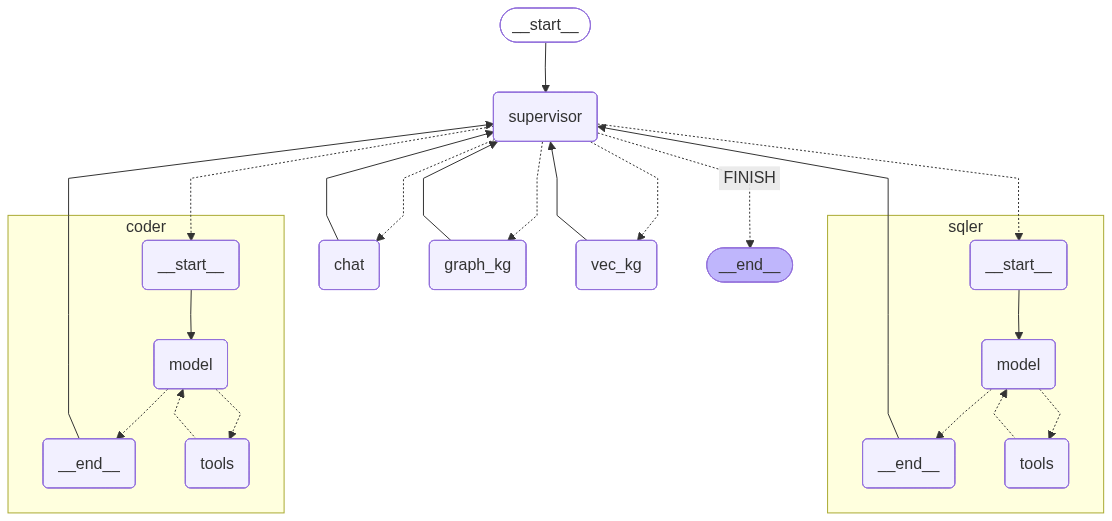

In [20]:
from IPython.display import display,Image

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
for chunk in graph.stream({"messages":"帮我查询id是5,6,7的销售记录的具体信息"},stream_mode="values"):
    print(chunk)

In [ ]:
for chunk in graph.stream({"messages":"帮我根据5,6,7的销售记录id，生成对应的销售额柱状图"},stream_mode="values"):
    print(chunk)

In [ ]:
for chunk in graph.stream({"messages":"帮我查询前10名的销售记录id，生成对应的销售额柱状图"},stream_mode="values"):
    print(chunk)

In [ ]:
for chunk in graph.stream({"messages":"帮我生成一个柱状图"},{"recursion_limit":20},stream_mode="values"):
    print(chunk)

In [21]:
for chunk in graph.stream({"messages":"都有哪些公司在数据库中"},{"recursion_limit":20},stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

都有哪些公司在数据库中
[防循环] agent 调用统计: {}
step count: 0, next: vec_kg
================================ Human Message =================================

都有哪些公司在数据库中
================================ Human Message =================================
Name: vec_kg

根据提供的上下文，数据库中提到的公司有：

- 苹果（Apple Inc.）
- 英特尔（Intel）
- 谷歌（Google）
- 华为技术有限公司（华为）
[防循环] agent 调用统计: {'vec_kg': 1}
step count: 1, next: vec_kg
================================ Human Message =================================
Name: vec_kg

根据提供的上下文，数据库中提到的公司有：

- 苹果（Apple Inc.）
- 英特尔（Intel）
- 谷歌（Google）
- 华为技术有限公司（华为）
================================ Human Message =================================
Name: vec_kg

根据提供的上下文，数据库中提到的公司有：

- 苹果（Apple Inc.）
- 英特尔（Intel）
- 谷歌（Google）
- 华为技术有限公司（华为）
[防循环] agent 调用统计: {'vec_kg': 2}
[硬编码纠正] vec_kg 已达上限，强制路由到: graph_kg
step count: 2, next: graph_kg
================================ Human Message =================================

AttributeError: 'CompiledStateGraph' object has no attribute 'get_structured_schema'